In [10]:
import pandas as pd
import bambi as bmb
import arviz as az
import arviz_plots as azp
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/fiodarzianiutsich/Desktop/projekt/data_cleaning/red_spruce_2022.csv')
df.columns

Index(['inventory_year', 'survey_unit', 'county', 'plot_number', 'tree_number',
       'diameter', 'height', 'SPCD', 'log_height', 'log_diameter'],
      dtype='str')

Here we define our advanced hierarchical model. We account for the macroclimate (the county level) by allowing both the baseline height (intercept) and the growth rate (slope) to vary.


In [11]:
model_formula = "log_height ~ log_diameter + (log_diameter | county)"

model = bmb.Model(model_formula, df)

In [12]:
results = model.fit(target_accept=0.99)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, log_diameter, 1|county_sigma, 1|county_offset, log_diameter|county_sigma, log_diameter|county_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 19 seconds.


In [13]:
az.summary(results, var_names=['Intercept', 'log_diameter', 'sigma', '1|county_sigma', 'log_diameter|county_sigma'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,0.172,0.058,0.059,0.276,0.001,0.001,7957.0,6448.0,1.0
log_diameter,0.791,0.021,0.749,0.831,0.000,0.000,6643.0,5956.0,1.0
sigma,0.205,0.008,0.191,0.221,0.000,0.000,9544.0,5537.0,1.0
1|county_sigma,0.083,0.043,0.001,0.154,0.001,0.001,2363.0,2608.0,1.0
log_diameter|county_sigma,0.033,0.016,0.000,0.060,0.000,0.000,2028.0,2046.0,1.0


In [14]:
tabel = az.summary(results)
tabel[tabel['r_hat'] > 1.05]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat


In [15]:
model

       Formula: log_height ~ log_diameter + (log_diameter | county)
        Family: gaussian
          Link: mu = identity
  Observations: 344
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 2.3727, sigma: 6.0911)
            log_diameter ~ Normal(mu: 0.0, sigma: 2.1495)
        
        Group-level effects
            1|county ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 6.0911))
            log_diameter|county ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.1495))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.6046)
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()

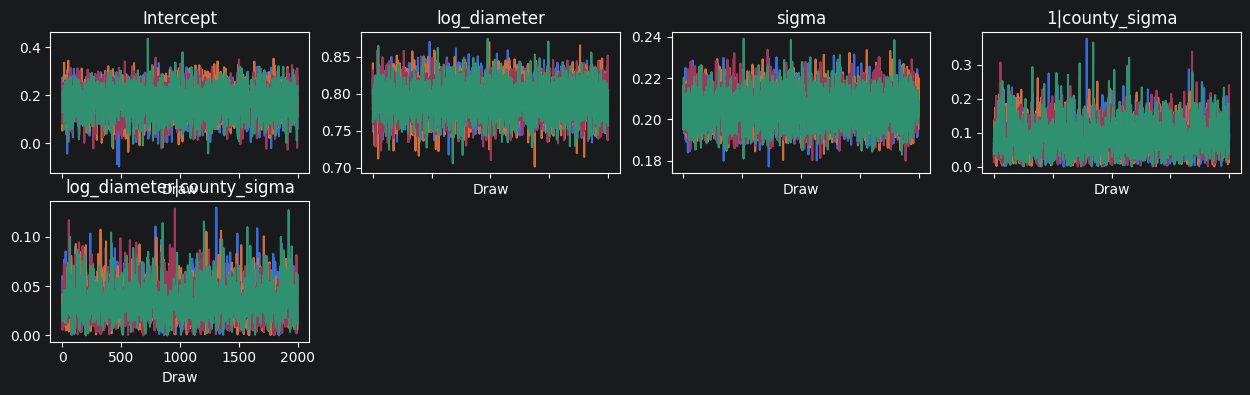

In [16]:
azp.plot_trace(results, var_names=['Intercept', 'log_diameter', 'sigma', '1|county_sigma', 'log_diameter|county_sigma'])

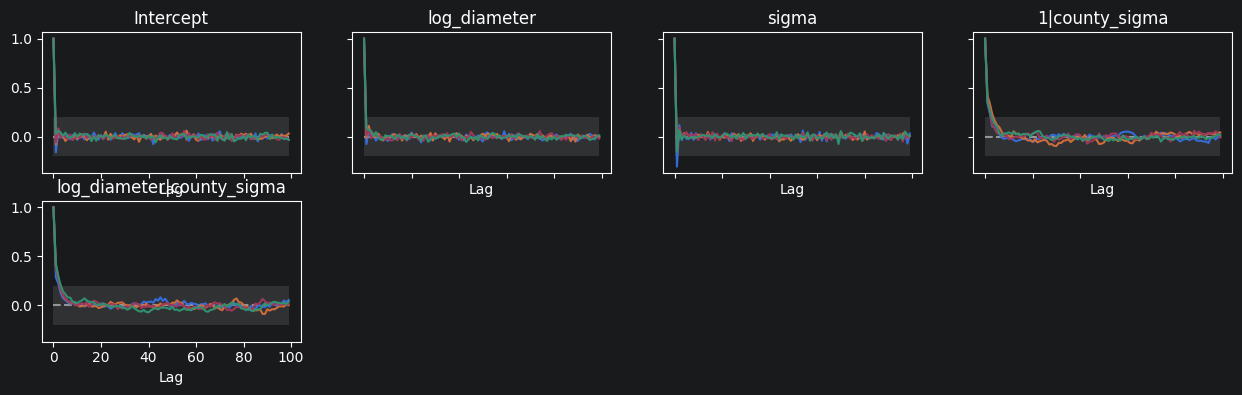

In [17]:
azp.plot_autocorr(results, var_names=['Intercept', 'log_diameter', 'sigma', '1|county_sigma', 'log_diameter|county_sigma'])

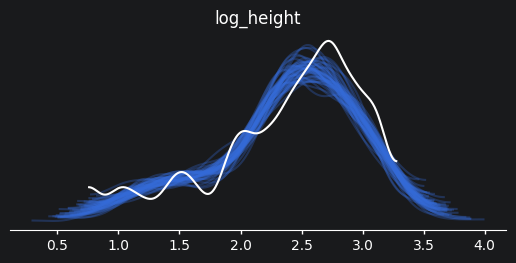

In [18]:
model.predict(results, kind="response")
azp.plot_ppc_dist(results)

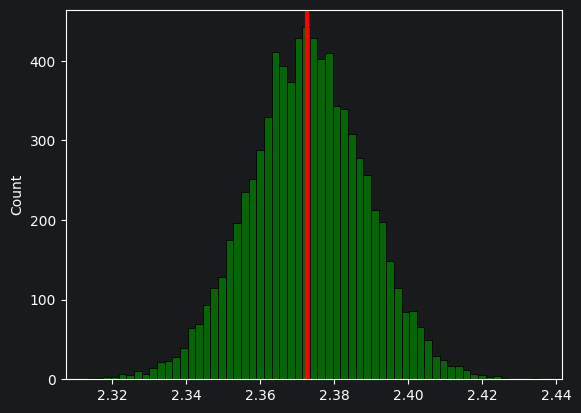

In [19]:
simulations = results.posterior_predictive['log_height'].mean(axis=-1).values.flatten()

sns.histplot(simulations, color='green')
plt.axvline(df['log_height'].mean(), color='red', linewidth=3)

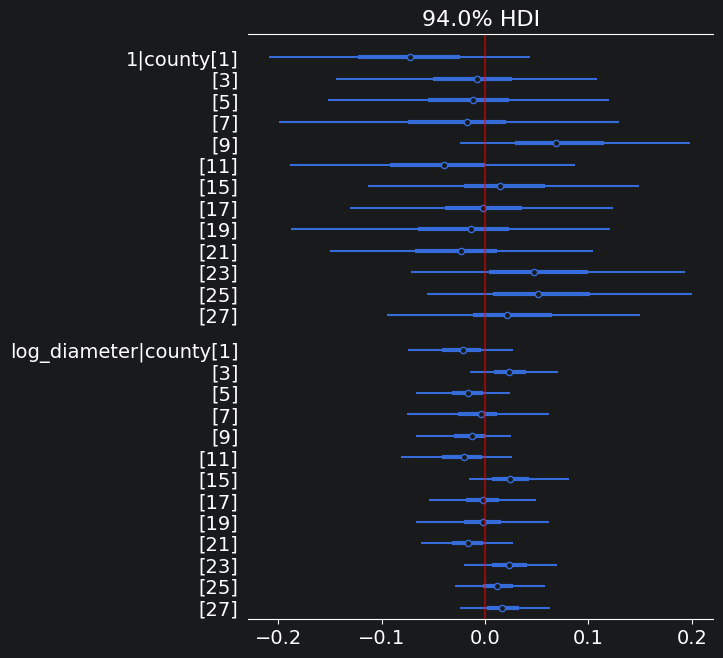

In [20]:
axes = az.plot_forest(results, var_names=["1|county", "log_diameter|county"], combined = True)
for ax in axes:
    ax.axvline(0, color='red', alpha=0.5)